Heart diease prediction project

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

Loading and visualizing data

In [12]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [13]:
hotVar = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df = pd.get_dummies(data = df, columns=hotVar, drop_first=True, dtype=int)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [14]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X, y

(     Age  RestingBP  Cholesterol  ...  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up
 0     40        140          289  ...                 0              0            1
 1     49        160          180  ...                 0              1            0
 2     37        130          283  ...                 0              0            1
 3     48        138          214  ...                 1              1            0
 4     54        150          195  ...                 0              0            1
 ..   ...        ...          ...  ...               ...            ...          ...
 913   45        110          264  ...                 0              1            0
 914   68        144          193  ...                 0              1            0
 915   57        130          131  ...                 1              1            0
 916   57        130          236  ...                 0              1            0
 917   38        138          175  ...                 0         

In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   Sex_M              918 non-null    int64  
 7   ChestPainType_ATA  918 non-null    int64  
 8   ChestPainType_NAP  918 non-null    int64  
 9   ChestPainType_TA   918 non-null    int64  
 10  RestingECG_Normal  918 non-null    int64  
 11  RestingECG_ST      918 non-null    int64  
 12  ExerciseAngina_Y   918 non-null    int64  
 13  ST_Slope_Flat      918 non-null    int64  
 14  ST_Slope_Up        918 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 107.7 KB


In [16]:
y.info()

<class 'pandas.Series'>
RangeIndex: 918 entries, 0 to 917
Series name: HeartDisease
Non-Null Count  Dtype
--------------  -----
918 non-null    int64
dtypes: int64(1)
memory usage: 7.3 KB


In [19]:
X.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.789760,0.188453,0.221133,0.050109,0.601307,0.193900,0.404139,0.501089,0.430283
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.407701,0.391287,0.415236,0.218289,0.489896,0.395567,0.490992,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
y.describe()

count    918.000000
mean       0.553377
std        0.497414
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: HeartDisease, dtype: float64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape

((734, 15), (92, 15), (92, 15), (734,), (92,), (92,))

ploting the data

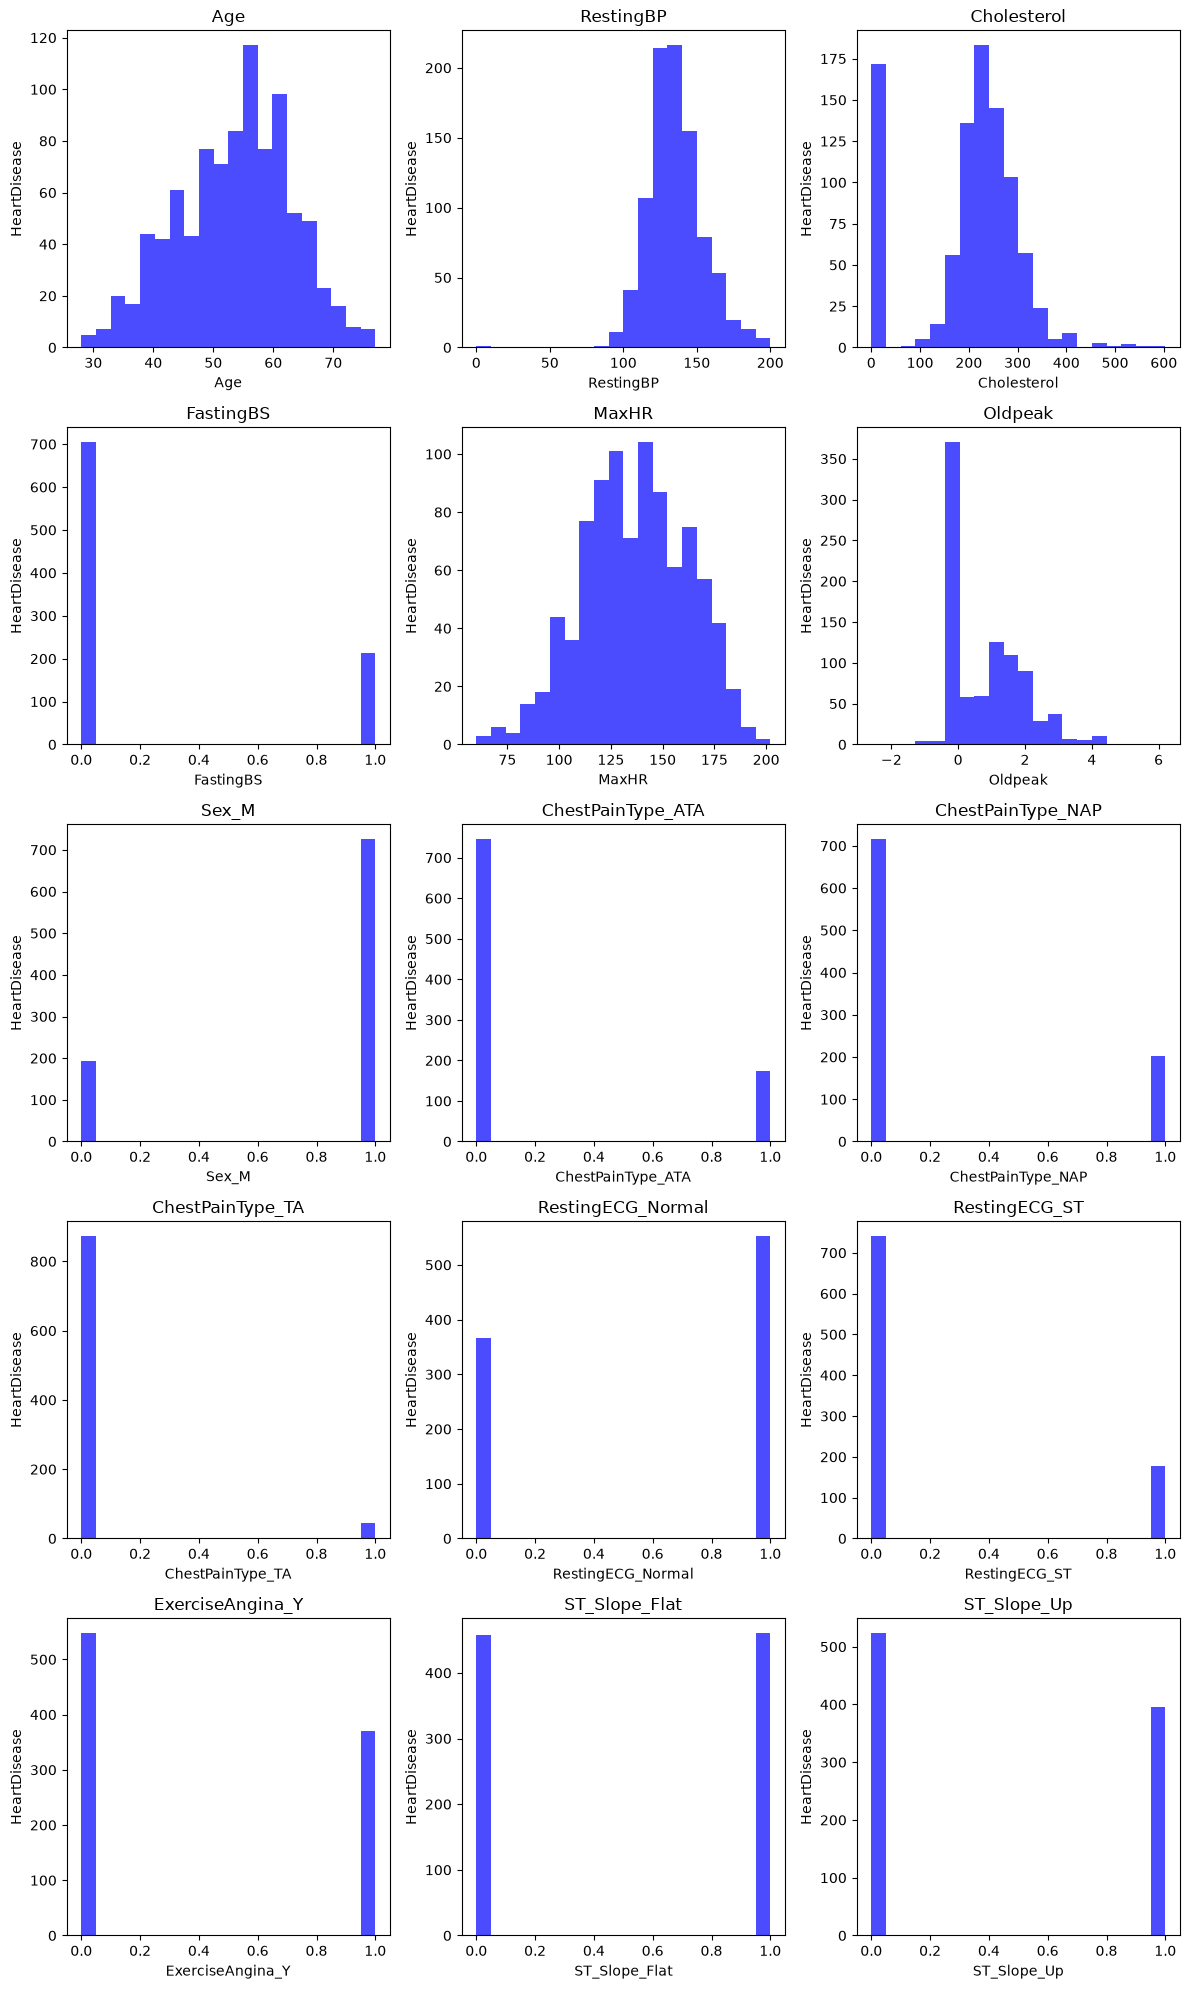

In [26]:
plt.subplots(5,3,figsize=(12, 20))
for i, col in enumerate(X.columns):
    plt.subplot(5, 3, i+1)
    plt.hist(X[col], bins=20, color='blue', alpha=0.7)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('HeartDisease')
    plt.tight_layout()
plt.show()

Declaring the models for testing

In [30]:
models = dict({
    'logistic_regression' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'decision_tree' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('classifier', DecisionTreeClassifier(max_depth=5))
    ]),
    'random_forest' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('classifier', RandomForestClassifier(n_estimators=300, max_depth=5, n_jobs=-1))
    ]),
    'gradient_boosting' : Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),
        ('classifier', GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.01))
    ])
})


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_val, y_pred)}")
    print(f"test Accuracy: {accuracy_score(y_test, y_test_pred)}")
    print(f"test ROC AUC Score: {roc_auc_score(y_test, y_test_pred)}")
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))
    print("\n\n")

Model: logistic_regression
Accuracy: 0.8586956521739131
ROC AUC Score: 0.859848484848485
test Accuracy: 0.8478260869565217
test ROC AUC Score: 0.8546481766820749
              precision    recall  f1-score   support

           0       0.74      0.88      0.81        33
           1       0.92      0.83      0.88        59

    accuracy                           0.85        92
   macro avg       0.83      0.85      0.84        92
weighted avg       0.86      0.85      0.85        92

[[29  4]
 [10 49]]



Model: decision_tree
Accuracy: 0.8586956521739131
ROC AUC Score: 0.8589015151515151
test Accuracy: 0.8586956521739131
test ROC AUC Score: 0.8430919363122753
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        33
           1       0.88      0.90      0.89        59

    accuracy                           0.86        92
   macro avg       0.85      0.84      0.85        92
weighted avg       0.86      0.86      0.86        92

[[26 

Gradient boosting model has high scores

In [31]:
best_model =models['gradient_boosting']
best_model.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','RestingBP','Cholesterol',...,'ExerciseAngina_Y','ST_Slope_Flat', 'ST_Slope_Up']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
